# 4. Explicabilité

In [31]:
import shap
import joblib
import pandas as pd
import numpy as np
from lime.lime_text import LimeTextExplainer
from pathlib import Path
import matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score

## SHAP

In [2]:
def print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance):

    indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[indices]

    X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

    features_names = vectorizer.get_feature_names_out()

    for i in list_dependance:
        idx = list(features_names).index(i)

        shap.partial_dependence_plot(
            idx,
            lambda x: clf.predict_proba(x)[:, 1],
            X_dense.values,
            feature_names=list(features_names), 
            ice=False,
            model_expected_value=True,
            feature_expected_value=True,
        )


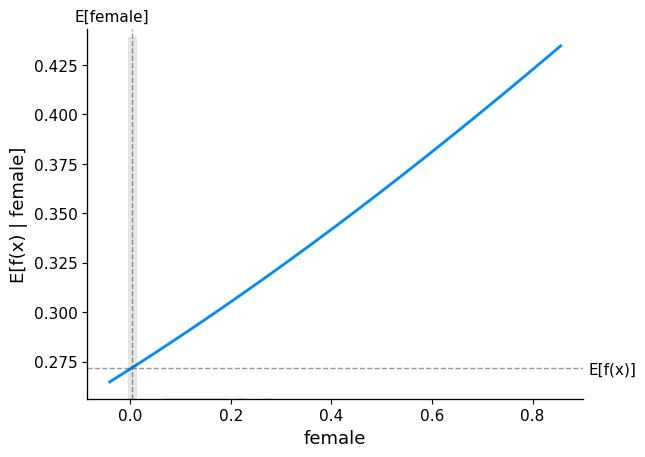

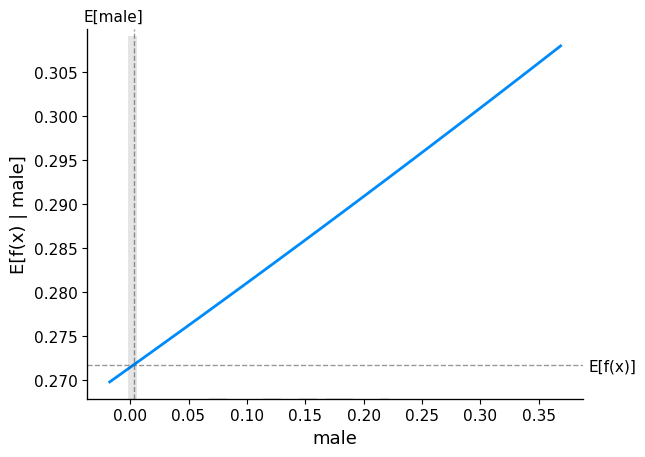

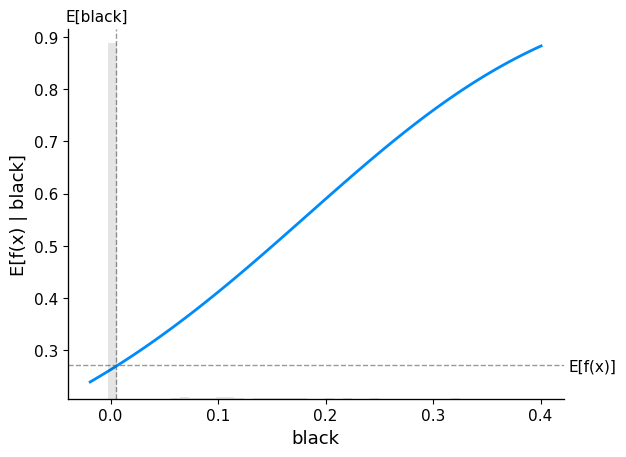

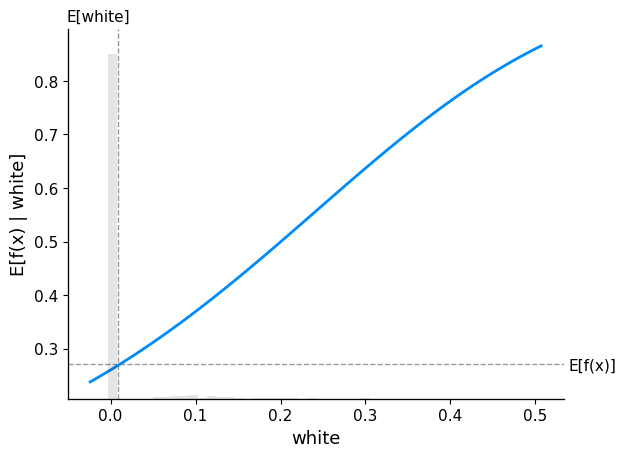

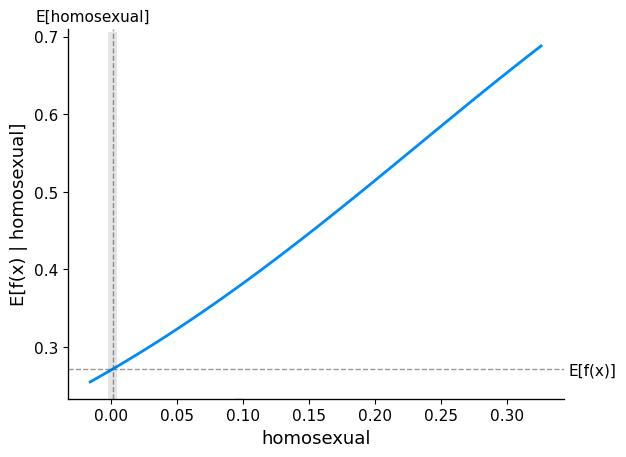

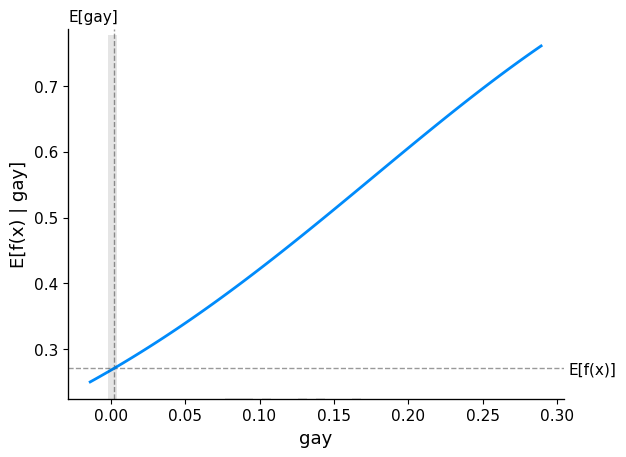

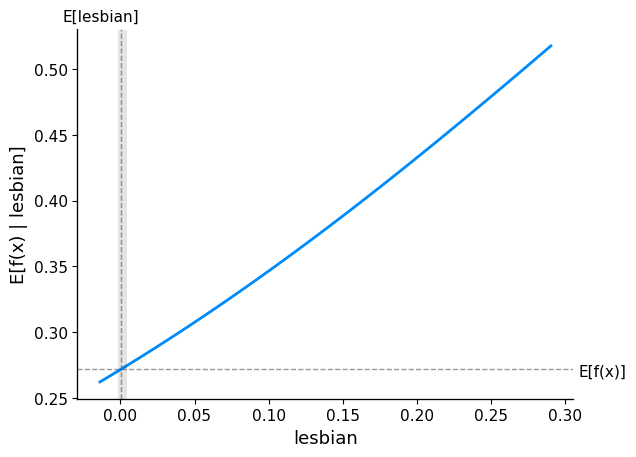

In [4]:
clf = joblib.load("logistic_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")
X = joblib.load("x_tfidf.pkl")

sample_size = 2000
list_dependance = ['female', 'male', 'black', 'white', 'homosexual', 'gay', 'lesbian']

print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance)

"black" et "white" montent jusqu'à 0.85-0.88 de proba de toxicité. Simplement mentionner une couleur de peau dans un texte le rend quasi-certain d'être prédit toxique.

"female" (0.43) contre "male" (0.31) montre que parler de femmes est plus souvent prédit toxique que parler d'hommes.

"gay" (0.75) et "homosexual" (0.69) ont une pente beaucoup plus forte que "lesbian" (0.52).

Les mots biaisés amplifient la toxicité.

### Waterfall SHAP pour une seule phrase aléatoire (prise dans un échantillon de 50 phrases)

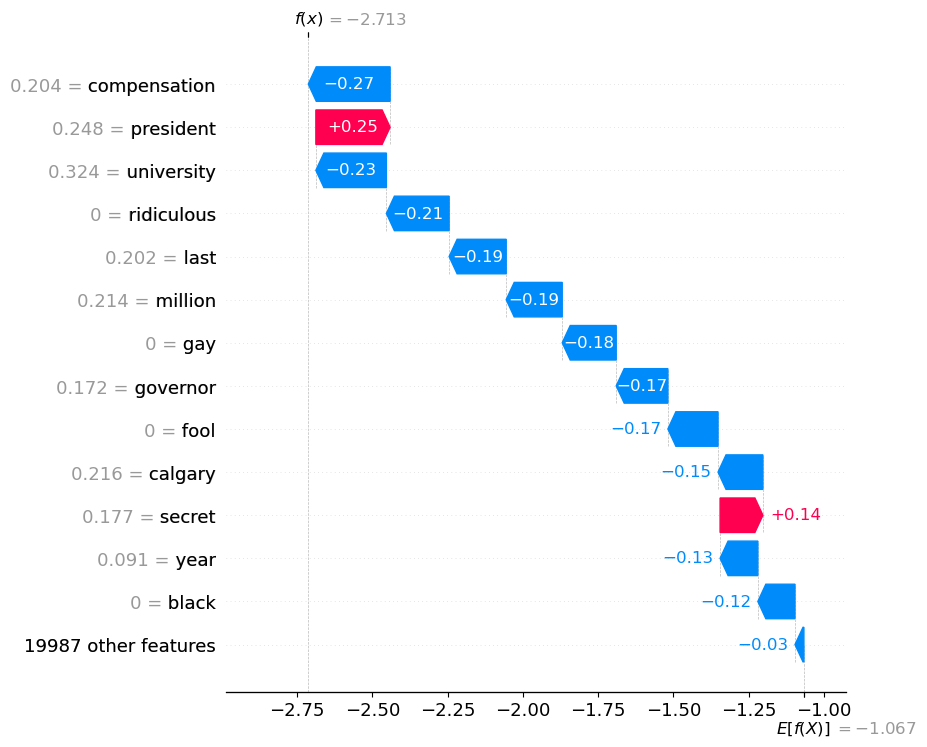

In [11]:
sample_size = 50
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[indices]
X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

X_background = shap.utils.sample(X_dense, 20)

explainer = shap.LinearExplainer(clf, X_background)  # ← background réduit
shap_values = explainer(X_dense)

sample_ind = 0
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

### Summary plot sur un échantillion de 50 phrases

C:\Users\fanny\AppData\Local\Temp\ipykernel_245284\797605708.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_dense, max_display=20)


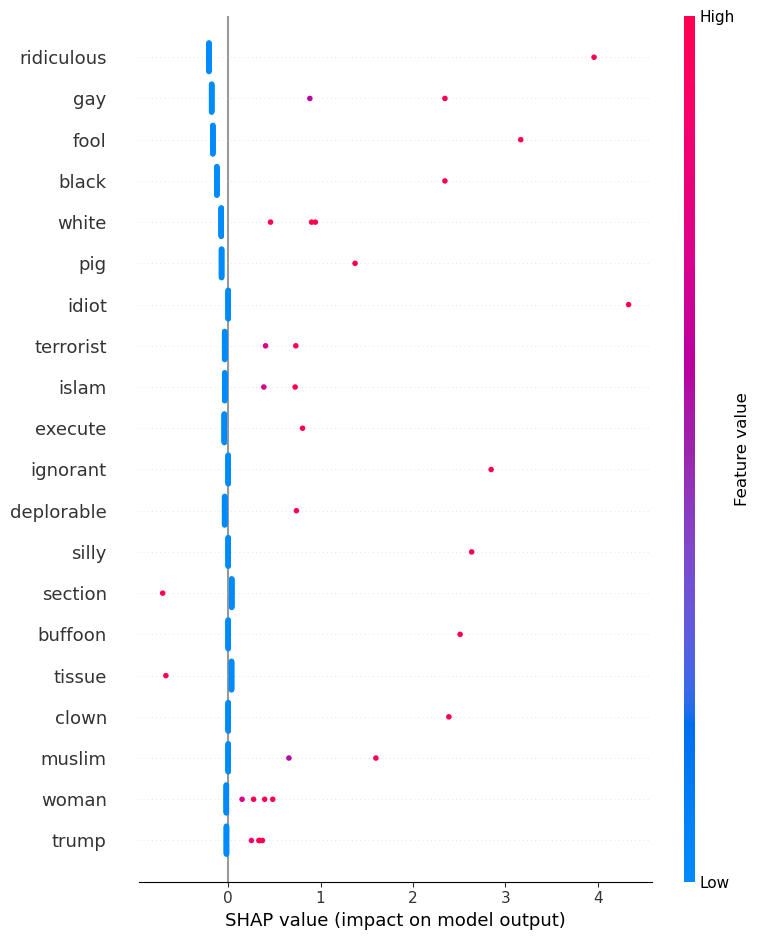

In [14]:
explainer = shap.LinearExplainer(clf, X_background)
shap_values = explainer(X_dense)

shap.summary_plot(shap_values, X_dense, max_display=20)

Tous les points à droite sont des mots qui poussent vers la toxicité du texte. (rose : TF-IDF élevé).

Le problème illustré ici est que les mots neutre ("black", "muslim"...) ont des values SHAP posiyive élévé donc le modèle associe la toxicité indépendemment du contexte.

## LIME

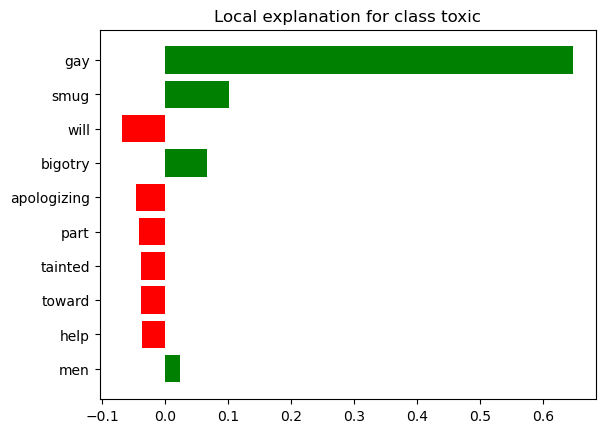

In [25]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

explainer = LimeTextExplainer(class_names=['non-toxic', 'toxic'])

def predict_proba_text(texts):
    X_vec = vectorizer.transform(texts)
    return clf.predict_proba(X_vec)

sentence_toxic = df[
    (df['comment_text'].str.contains("gay", case=False, na=False)) &
    (df['toxicity'] >= 0.5)
]['comment_text']


exp = explainer.explain_instance(sentence_toxic.iloc[0], predict_proba_text, num_features=10)
exp.as_pyplot_figure()
plt.show()

Ici le biais est très visible avec le mot "gay". De plus le mot "bigotry" qui décris un comportement négatif à un faible impacte sur le taux de toxicité.

# 5. Fairness

## Fairness du dataset

In [37]:
sensitive_cols = ['female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian']

for col in sensitive_cols:
    subset = df[df[col] >= 0.5]
    taux = (subset['toxicity'] >= 0.5).mean()
    print(f"{col} : {len(subset)} phrases; taux toxicité : {taux}")

female : 58584 phrases; taux toxicité : 0.1366072647821931
male : 48870 phrases; taux toxicité : 0.1505013300593411
black : 16420 phrases; taux toxicité : 0.31552984165651643
white : 27534 phrases; taux toxicité : 0.28255974431611824
homosexual_gay_or_lesbian : 12062 phrases; taux toxicité : 0.28278892389321836


## Fairness du modèle

In [38]:
df = df.dropna(subset=['comment_text', 'toxicity'])
df['comment_text'] = df['comment_text'].astype(str)
df = df.reset_index(drop=True)


def fairness_model(sensitive_word):
    sensitive = df[sensitive_word] >= 0.5 
    y_true = (df['toxicity'] >= 0.5).astype(int)
    X_all = vectorizer.transform(df["comment_text"])
    y_pred = clf.predict(X_all)

    mf = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'fpr': false_positive_rate,
            'fnr': false_negative_rate,
            'selection_rate': selection_rate
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    print(mf.by_group)
    mf.by_group.plot(kind='bar', figsize=(10, 5))
    plt.title(f"Fairness par groupe {sensitive_word}")
    plt.show()

        accuracy       fpr       fnr  selection_rate
female                                              
False   0.770198  0.231600  0.215232        0.292385
True    0.689096  0.329017  0.196426        0.393845


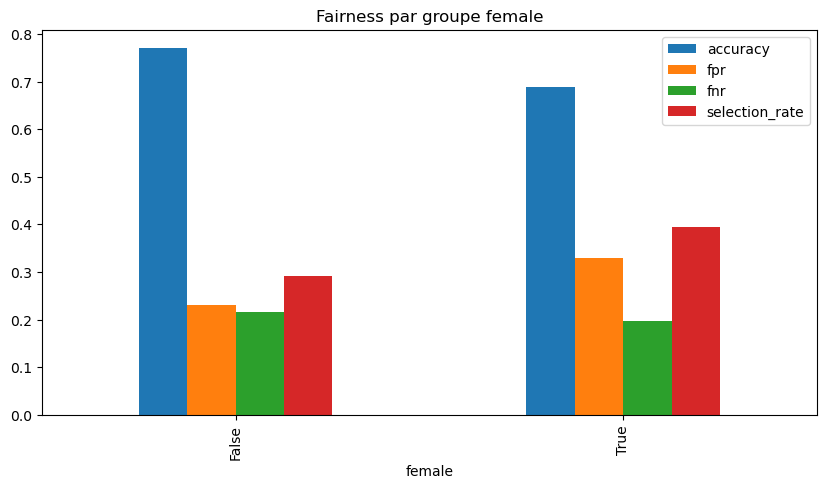

       accuracy       fpr       fnr  selection_rate
male                                               
False  0.769856  0.231014  0.223025        0.290433
True   0.675772  0.355317  0.148742        0.429957


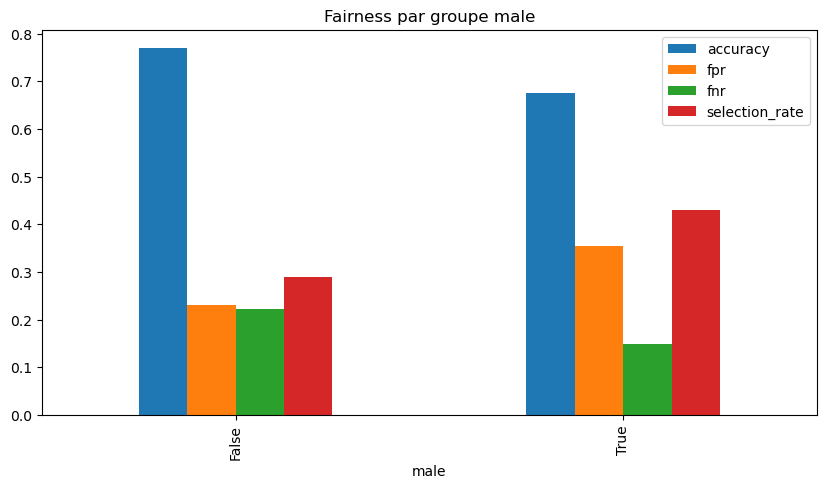

       accuracy       fpr       fnr  selection_rate
black                                              
False  0.768647  0.232508  0.221582        0.290205
True   0.521620  0.638847  0.130284        0.711693


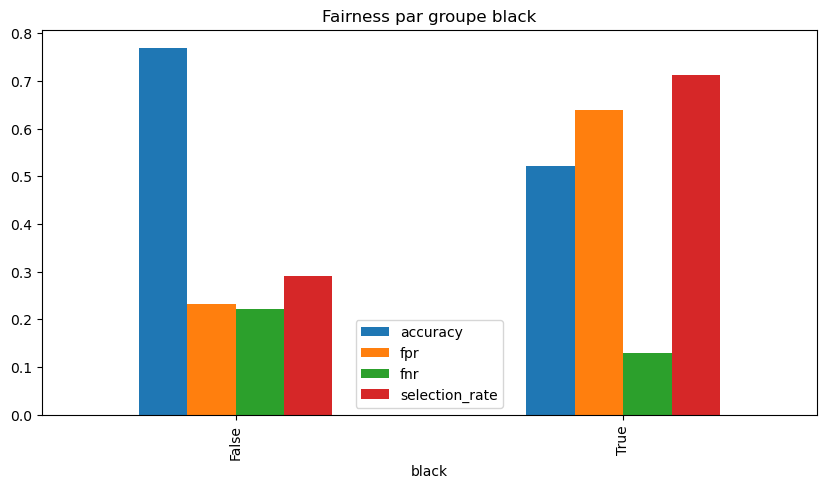

       accuracy       fpr       fnr  selection_rate
white                                              
False  0.773702  0.225988  0.229018        0.281741
True   0.544127  0.588286  0.119666        0.670807


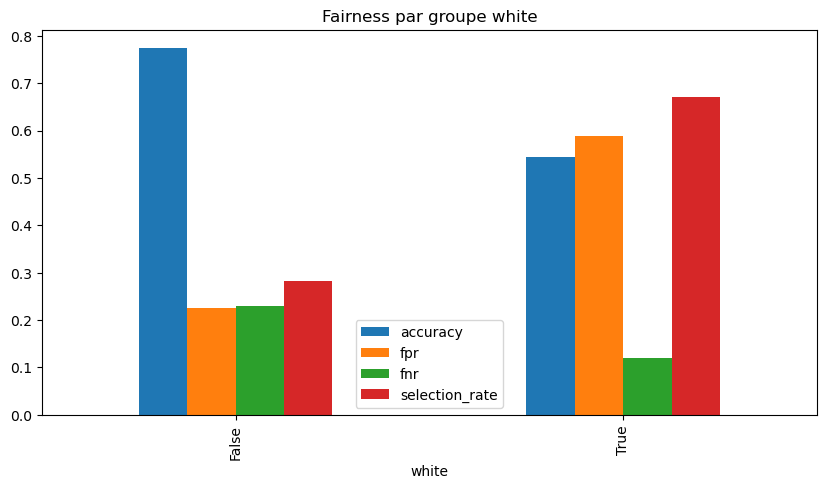

                           accuracy       fpr       fnr  selection_rate
homosexual_gay_or_lesbian                                              
False                      0.765690  0.236632  0.215267        0.296206
True                       0.539214  0.575194  0.170624        0.647073


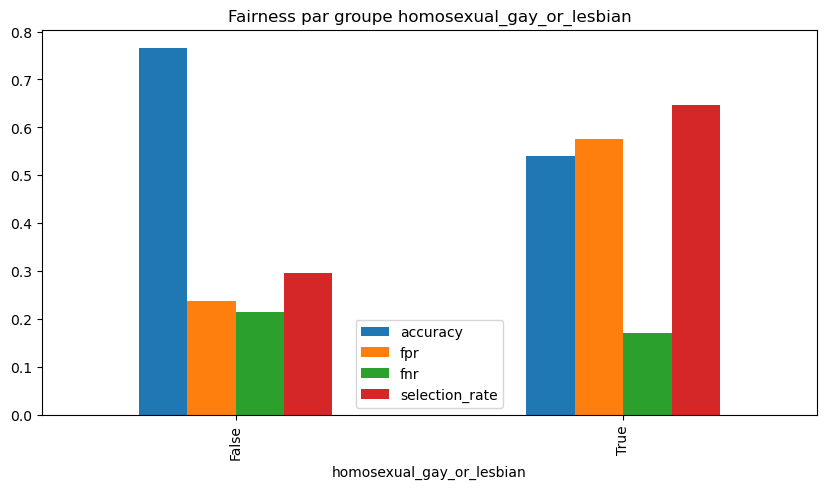

In [39]:
for word in sensitive_cols:
    fairness_model(word)    

Ici False signifie que le texte ne parle pas du groupe et True si.

Pour le groupe homosexuel le modèle prédit a tort que ce groupe est toxique presque 2 fois plus souvent. (FPR)

Le gap de faux positif est beaucoup moins important pour les groupes homme et femme.

Les groupes noir et blanc sont similairement biaisés. Le modèle est aussi sévère avec les textes parlant de personnes blanches que noires. Ce qui suggère que le biais est de couleur de peaux en général plutôt que dirigé vers une couelur spécifique.

## Conclusion partie (3/3)

Dans le dataset Civil Comments WILDS, des annotateurs humains ont évalué des commentaires selon deux axes : la présence de groupes identitaires mentionnés (colonnes black, female, gay...) et le niveau de toxicité du texte. Ce processus d'annotation introduit des biais humains inconscients, les commentaires mentionnant des minorités ayant tendance à être sur-étiquetés comme toxiques, même lorsque leur contenu est neutre ou positif.


Un modèle de régression logistique a ensuite été entraîné à prédire la toxicité à partir des mots du texte (représentés via une matrice TF-IDF). En apprenant sur ces données biaisées, le modèle reproduit les biais présents dans les annotations.


Pour analyser ce phénomène, deux approches complémentaires ont été utilisées. D'une part, SHAP permet d'expliquer les décisions du modèle au niveau des mots : sans utiliser les colonnes annotées manuellement, il révèle que des termes comme black, gay ou female poussent fortement la prédiction vers la toxicité reflétant indirectement les biais humains encodés dans la colonne toxicity. D'autre part, Fairlearn quantifie ces biais au niveau des groupes en utilisant directement les colonnes annotées manuellement (black, female, gay...) comme variables sensibles. Il compare les métriques de performance (FPR, FNR, selection rate) entre les commentaires annotés comme mentionnant un groupe sensible (True) et ceux qui ne le mentionnent pas (False).


SHAP, sans jamais accéder aux colonnes identitaires, arrive aux mêmes conclusions que Fairlearn qui les utilise explicitement ce qui confirme que le biais est profondément encré dans le modèle.